# 11. Modelado Predictivo por Tipología (SARIMAX vs XGBoost)

Benchmark Out-of-Sample (Oct-Dic 2025) para cada cluster de entidades territoriales.

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.statespace.sarimax import SARIMAX
import xgboost as xgb
import warnings; warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')


In [2]:
# Reconstruir panel y tipologías
df = pd.read_excel('../BaseRentasVF_2022_2025.xlsx')
df['FechaRecaudo'] = pd.to_datetime(df['FechaRecaudo'])
df = df[df['FechaRecaudo'] >= '2022-01-01'].copy()
panel = df.groupby([df['NombreBeneficiarioAportante'], df['FechaRecaudo'].dt.to_period('M')])['ValorRecaudo'].sum().reset_index()
panel.columns = ['Entidad', 'Periodo', 'Recaudo']
panel['Fecha'] = panel['Periodo'].dt.to_timestamp()
conteo = panel.groupby('Entidad')['Periodo'].count()
panel = panel[panel['Entidad'].isin(conteo[conteo>=24].index)].copy()
stats = panel.groupby('Entidad')['Recaudo'].agg(['mean','sum','std']).reset_index()
stats['CV'] = (stats['std']/stats['mean'].replace(0,np.nan)).fillna(0)
features_km = np.column_stack([np.log1p(stats['sum'].clip(lower=0).values), stats['CV'].clip(upper=10).values])
stats['Cluster'] = KMeans(n_clusters=4, random_state=42, n_init=10).fit_predict(features_km)
cr = stats.groupby('Cluster')['sum'].mean().sort_values(ascending=False).index
stats['Tipologia'] = stats['Cluster'].map({cr[0]:'1_Consolidados',cr[1]:'2_Emergentes',cr[2]:'3_Dependientes',cr[3]:'4_Críticos'})
panel = panel.merge(stats[['Entidad','Tipologia']], on='Entidad', how='left')
print("Panel reconstruido.")


Panel reconstruido.


## Backtesting: SARIMAX vs XGBoost por Tipología

In [3]:
fecha_corte = pd.Timestamp('2025-09-30')
tipologias = sorted(panel['Tipologia'].dropna().unique())
resultados = []

for tipo in tipologias:
    serie = panel[panel['Tipologia']==tipo].groupby('Fecha')['Recaudo'].sum().sort_index()
    serie.index = pd.DatetimeIndex(serie.index)
    serie = serie.asfreq('MS', fill_value=0)
    train, test = serie[serie.index <= fecha_corte], serie[serie.index > fecha_corte]
    if len(test) == 0: continue
    
    # SARIMAX
    try:
        fit = SARIMAX(train, order=(1,1,1), seasonal_order=(0,1,1,12),
                      enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
        pred = fit.forecast(steps=len(test))
        mape_s = np.mean(np.abs((test.values-pred.values)/np.where(test.values!=0,test.values,1)))*100
        resultados.append({'Tipologia':tipo,'Modelo':'SARIMAX','MAPE':round(mape_s,2)})
    except: pass
    
    # XGBoost
    try:
        df_x = pd.DataFrame({'Recaudo':serie})
        df_x['L1'],df_x['L2'],df_x['L12'] = df_x['Recaudo'].shift(1),df_x['Recaudo'].shift(2),df_x['Recaudo'].shift(12)
        df_x['Mes'],df_x['Tri'] = df_x.index.month, df_x.index.quarter
        df_x = df_x.dropna()
        feats = ['L1','L2','L12','Mes','Tri']
        tr, te = df_x[df_x.index<=fecha_corte], df_x[df_x.index>fecha_corte]
        m = xgb.XGBRegressor(n_estimators=100, max_depth=3, learning_rate=0.05, objective='reg:absoluteerror')
        m.fit(tr[feats], tr['Recaudo'])
        p = m.predict(te[feats])
        mape_x = np.mean(np.abs((te['Recaudo'].values-p)/np.where(te['Recaudo'].values!=0,te['Recaudo'].values,1)))*100
        resultados.append({'Tipologia':tipo,'Modelo':'XGBoost','MAPE':round(mape_x,2)})
    except: pass

df_res = pd.DataFrame(resultados)
display(df_res.pivot(index='Tipologia', columns='Modelo', values='MAPE'))


Modelo,SARIMAX,XGBoost
Tipologia,,
1_Consolidados,14.55,6.61
2_Emergentes,7.87,6.66
3_Dependientes,29.79,5.51
4_Críticos,40.84,7.77


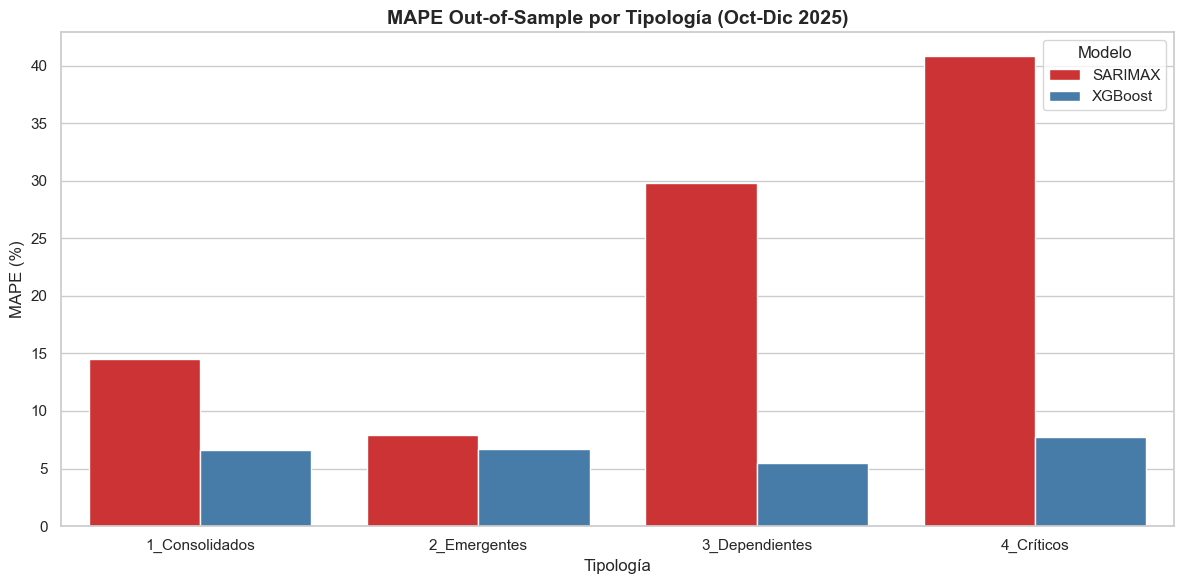

In [4]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=df_res, x='Tipologia', y='MAPE', hue='Modelo', palette='Set1', ax=ax)
ax.set_title('MAPE Out-of-Sample por Tipología (Oct-Dic 2025)', fontweight='bold', fontsize=14)
ax.set_ylabel('MAPE (%)'); ax.set_xlabel('Tipología')
plt.tight_layout(); plt.show()
